In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Indian_Kids_Screen_Time.csv")
print(df.head())
print(df.info())
print(df.describe())


   Age  Gender  Avg_Daily_Screen_Time_hr Primary_Device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   Exceeded_Recommended_Limit  Educational_to_Recreational_Ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           Health_Impacts Urban_or_Rural  
0  Poor Sleep, Eye Strain          Urban  
1              Poor Sleep          Urban  
2              Poor Sleep          Urban  
3                     NaN          Urban  
4     Poor Sleep, Anx

In [ ]:
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else "Unknown")


In [ ]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns.tolist())


['age', 'gender', 'avg_daily_screen_time_hr', 'primary_device', 'exceeded_recommended_limit', 'educational_to_recreational_ratio', 'health_impacts', 'urban_or_rural']


In [ ]:
if 'device' in df.columns:
    df['device'] = df['device'].str.strip().str.lower()
    df['device'] = df['device'].replace({
        'smartphone':'mobile',
        'phone':'mobile',
        'tv':'television',
        'tab':'tablet'
    })

if 'activity' in df.columns:
    df['activity'] = df['activity'].str.strip().str.lower()
    df['activity'] = df['activity'].replace({
        'study':'education',
        'homework':'education',
        'learning':'education',
        'games':'entertainment',
        'youtube':'entertainment'
    })


In [ ]:
if 'age' in df.columns:
    def age_band(age):
        if age <= 5: return "Toddler"
        elif age <= 10: return "Child"
        elif age <= 15: return "Pre-Teen"
        else: return "Teen"
    df['age_band'] = df['age'].apply(age_band)

if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['weekend_flag'] = df['date'].dt.dayofweek.apply(lambda x: 1 if x >= 5 else 0)
    df['day_of_week'] = df['date'].dt.day_name()


In [ ]:
if {'child_id','date','screen_time_hours'}.issubset(df.columns):
    df['device_share'] = df.groupby(['child_id','date'])['screen_time_hours'].transform(lambda x: x / x.sum())
    df['activity_share'] = df.groupby(['child_id','date'])['screen_time_hours'].transform(lambda x: x / x.sum())


In [ ]:
df.to_csv("Indian_Kids_Screen_Time_Cleaned.csv", index=False)

with open("Preprocessing_Summary.txt", "w") as f:
    f.write("Preprocessing Summary:\n")
    f.write("- Missing numeric values filled with median.\n")
    f.write("- Missing categorical values filled with mode or 'Unknown'.\n")
    f.write("- Device and Activity categories normalized if present.\n")
    f.write("- Age bands created if Age column exists.\n")
    f.write("- Weekend flag derived from Date if present.\n")
    f.write("- Device and Activity shares calculated if Child_ID, Date, and Screen_Time_Hours exist.\n")
    f.write("- Dates formatted to ISO 8601 if present.\n")

print("✅ Preprocessing complete. Cleaned dataset and summary saved.")


✅ Preprocessing complete. Cleaned dataset and summary saved.


In [ ]:
import pandas as pd
df_cleaned = pd.read_csv("Indian_Kids_Screen_Time_Cleaned.csv")


In [ ]:
print(df_cleaned.head())


   age  gender  avg_daily_screen_time_hr primary_device  \
0   14    Male                      3.99     Smartphone   
1   11  Female                      4.61         Laptop   
2   18  Female                      3.73             TV   
3   15  Female                      1.21         Laptop   
4   12  Female                      5.89     Smartphone   

   exceeded_recommended_limit  educational_to_recreational_ratio  \
0                        True                               0.42   
1                        True                               0.30   
2                        True                               0.32   
3                       False                               0.39   
4                        True                               0.49   

           health_impacts urban_or_rural  age_band  
0  Poor Sleep, Eye Strain          Urban  Pre-Teen  
1              Poor Sleep          Urban  Pre-Teen  
2              Poor Sleep          Urban      Teen  
3              Poor Slee

In [ ]:
import pandas as pd

df = pd.read_csv("Indian_Kids_Screen_Time_Cleaned.csv")
print(df.columns.tolist())


['age', 'gender', 'avg_daily_screen_time_hr', 'primary_device', 'exceeded_recommended_limit', 'educational_to_recreational_ratio', 'health_impacts', 'urban_or_rural', 'age_band']


**univariate analysis**

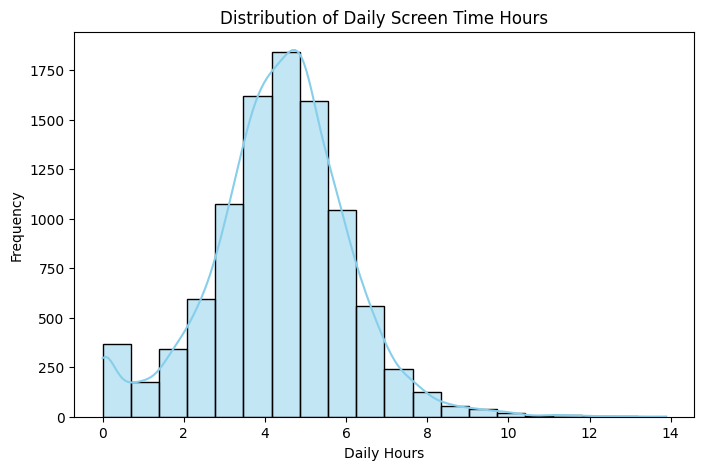

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['avg_daily_screen_time_hr'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Daily Screen Time Hours")
plt.xlabel("Daily Hours")
plt.ylabel("Frequency")
plt.show()


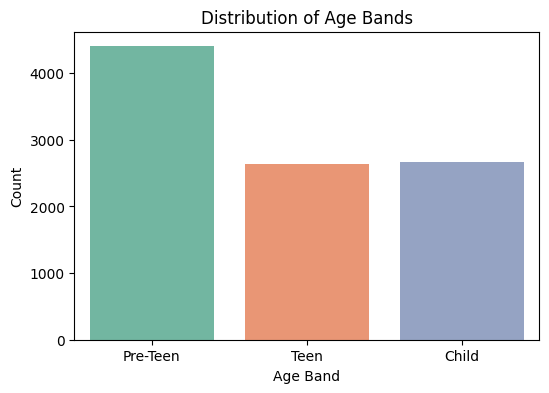

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='age_band',
    hue='age_band',
    data=df,
    palette='Set2',
    legend=False
)
plt.title("Distribution of Age Bands")
plt.xlabel("Age Band")
plt.ylabel("Count")
plt.show()


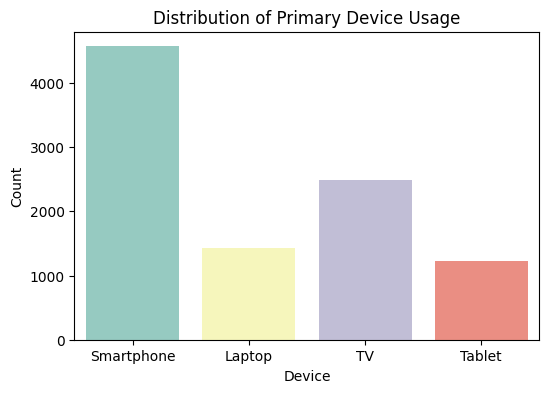

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(
    x='primary_device',
    hue='primary_device',
    data=df,
    palette='Set3',
    legend=False
)
plt.title("Distribution of Primary Device Usage")
plt.xlabel("Device")
plt.ylabel("Count")
plt.show()


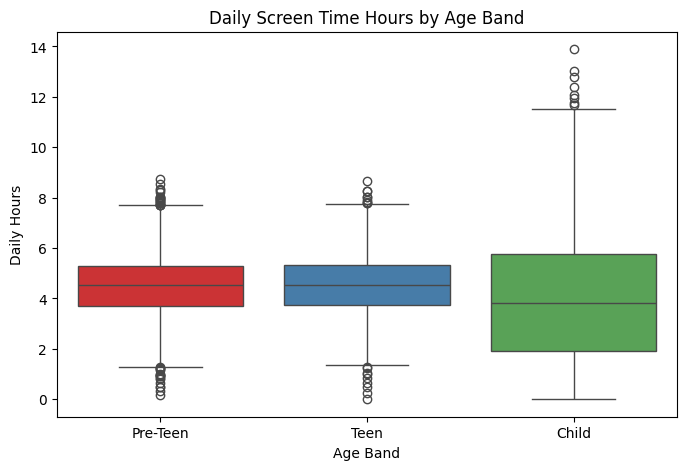

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='age_band',
    y='avg_daily_screen_time_hr',
    hue='age_band',
    data=df,
    palette='Set1',
    legend=False
)
plt.title("Daily Screen Time Hours by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Daily Hours")
plt.show()


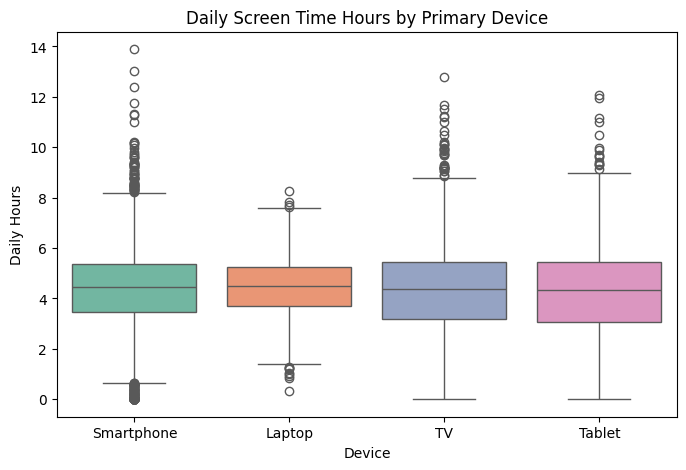

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='primary_device',
    y='avg_daily_screen_time_hr',
    hue='primary_device',
    data=df,
    palette='Set2',
    legend=False
)
plt.title("Daily Screen Time Hours by Primary Device")
plt.xlabel("Device")
plt.ylabel("Daily Hours")
plt.show()


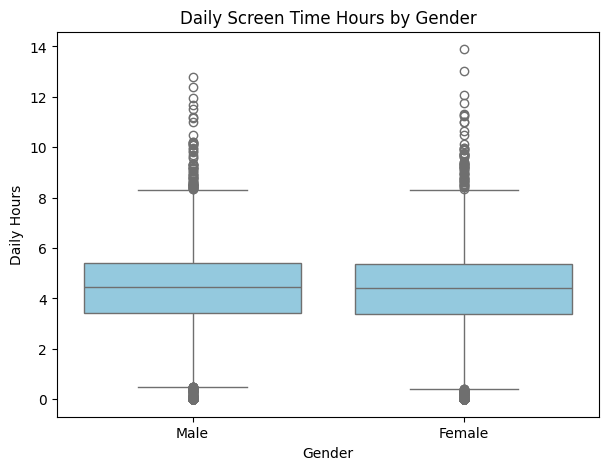

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x='gender',
    y='avg_daily_screen_time_hr',
    data=df,
    color='skyblue'
)
plt.title("Daily Screen Time Hours by Gender")
plt.xlabel("Gender")
plt.ylabel("Daily Hours")
plt.show()


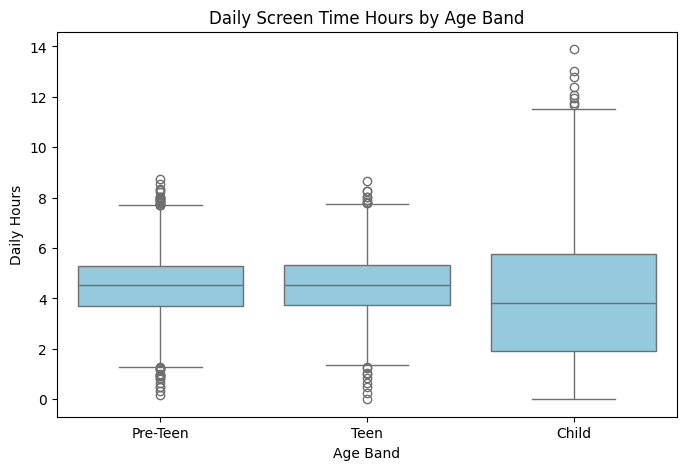

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='age_band',
    y='avg_daily_screen_time_hr',
    data=df,
    color='skyblue'
)
plt.title("Daily Screen Time Hours by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Daily Hours")
plt.show()


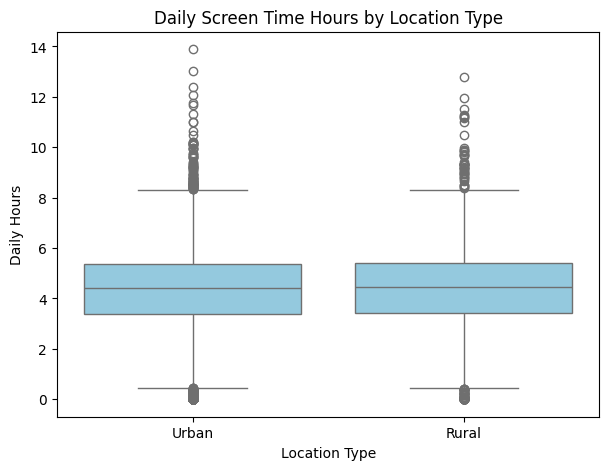

In [ ]:
plt.figure(figsize=(7,5))
sns.boxplot(
    x='urban_or_rural',
    y='avg_daily_screen_time_hr',
    data=df,
    color='skyblue'
)
plt.title("Daily Screen Time Hours by Location Type")
plt.xlabel("Location Type")
plt.ylabel("Daily Hours")
plt.show()


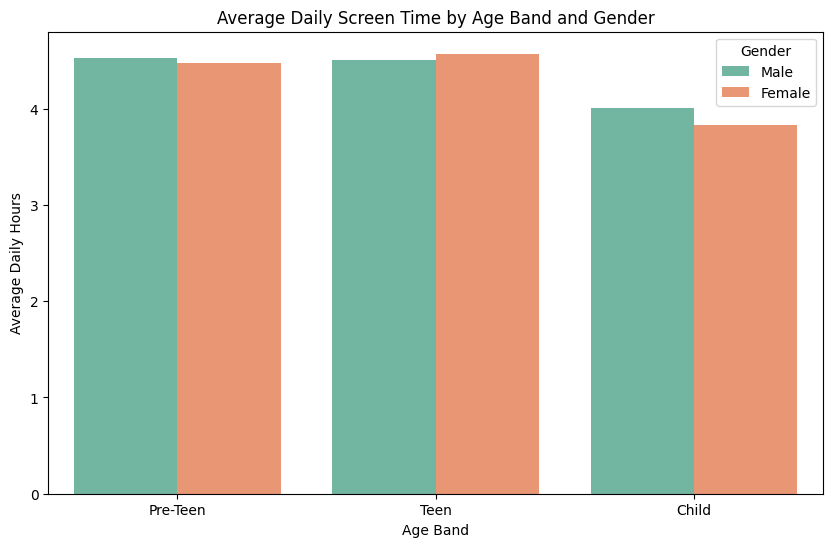

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='age_band',
    y='avg_daily_screen_time_hr',
    hue='gender',
    data=df,
    errorbar=None,
    palette='Set2'
)
plt.title("Average Daily Screen Time by Age Band and Gender")
plt.xlabel("Age Band")
plt.ylabel("Average Daily Hours")
plt.legend(title="Gender")
plt.show()

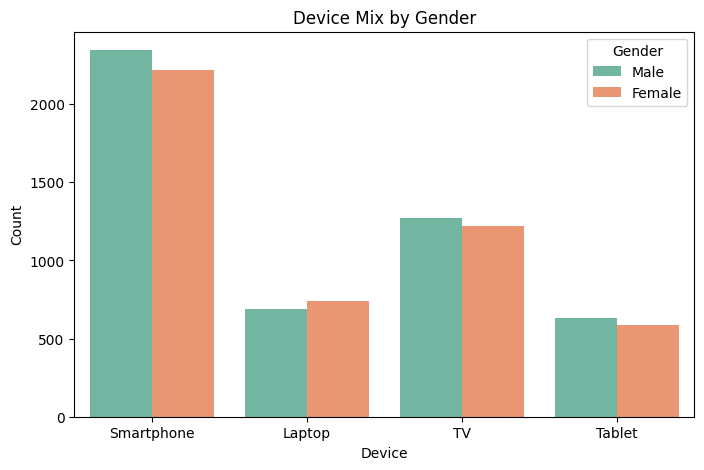

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='primary_device', hue='gender', data=df, palette='Set2')
plt.title("Device Mix by Gender")
plt.xlabel("Device")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.show()


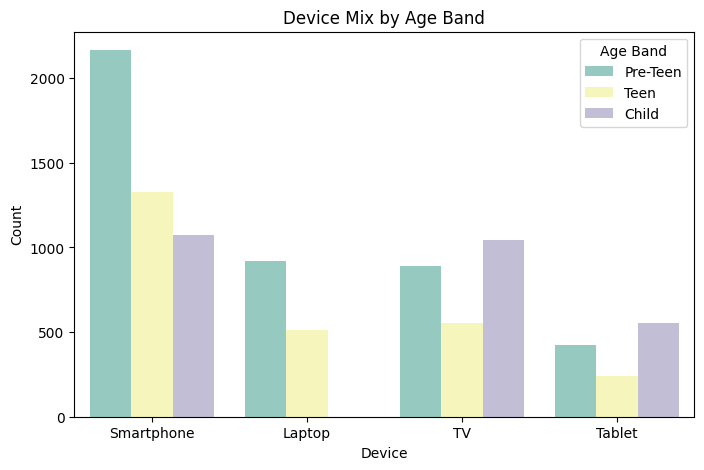

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='primary_device', hue='age_band', data=df, palette='Set3')
plt.title("Device Mix by Age Band")
plt.xlabel("Device")
plt.ylabel("Count")
plt.legend(title="Age Band")
plt.show()


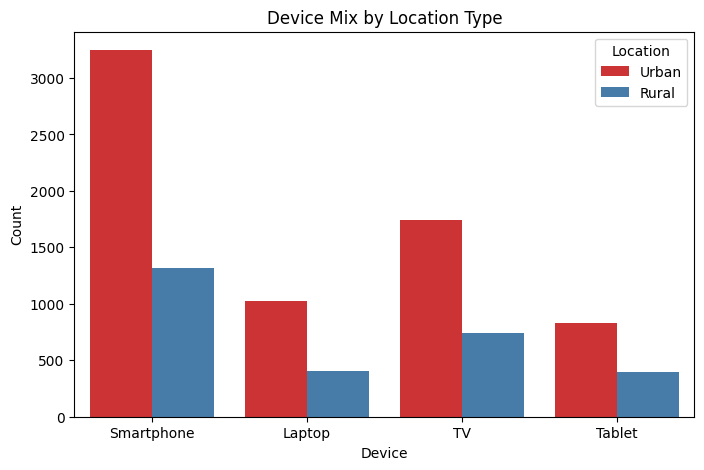

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='primary_device', hue='urban_or_rural', data=df, palette='Set1')
plt.title("Device Mix by Location Type")
plt.xlabel("Device")
plt.ylabel("Count")
plt.legend(title="Location")
plt.show()


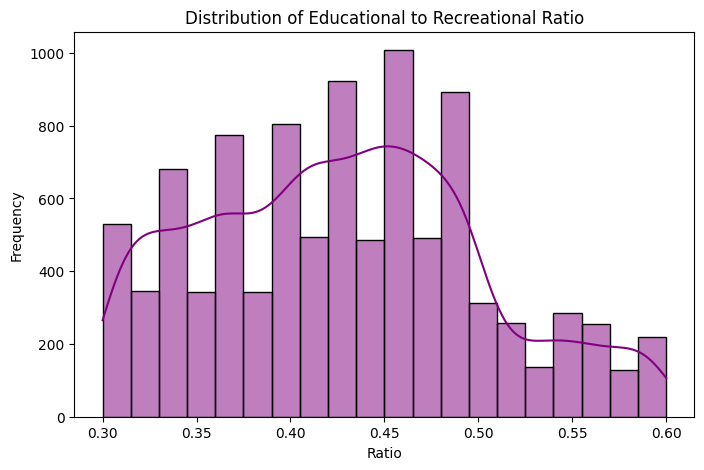

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['educational_to_recreational_ratio'], bins=20, kde=True, color='purple')
plt.title("Distribution of Educational to Recreational Ratio")
plt.xlabel("Ratio")
plt.ylabel("Frequency")
plt.show()


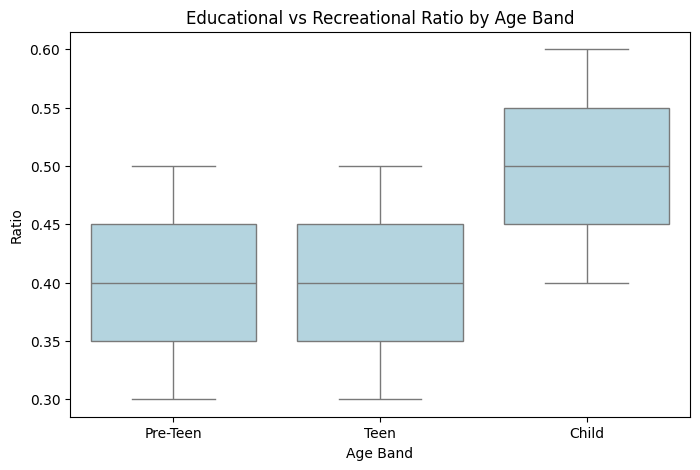

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='age_band', y='educational_to_recreational_ratio', data=df, color='lightblue')
plt.title("Educational vs Recreational Ratio by Age Band")
plt.xlabel("Age Band")
plt.ylabel("Ratio")
plt.show()


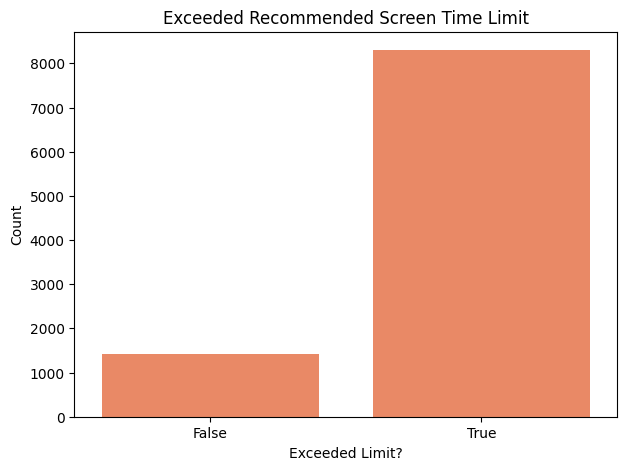

In [ ]:
plt.figure(figsize=(7,5))
sns.countplot(x='exceeded_recommended_limit', data=df, color='coral')
plt.title("Exceeded Recommended Screen Time Limit")
plt.xlabel("Exceeded Limit?")
plt.ylabel("Count")
plt.show()


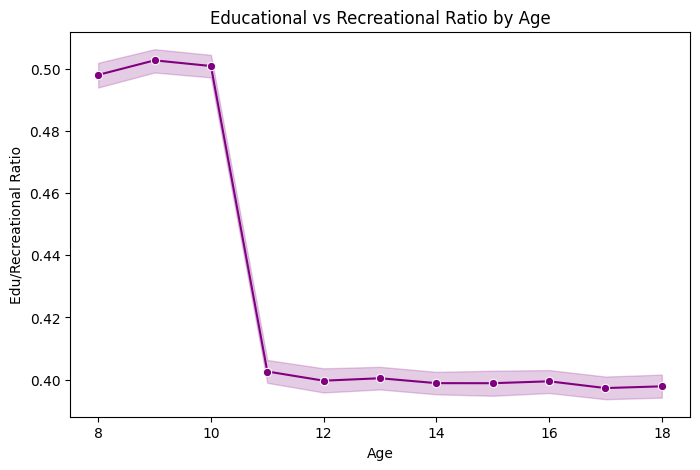

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(x='age', y='educational_to_recreational_ratio', data=df, marker='o', color='purple')
plt.title("Educational vs Recreational Ratio by Age")
plt.xlabel("Age")
plt.ylabel("Edu/Recreational Ratio")
plt.show()


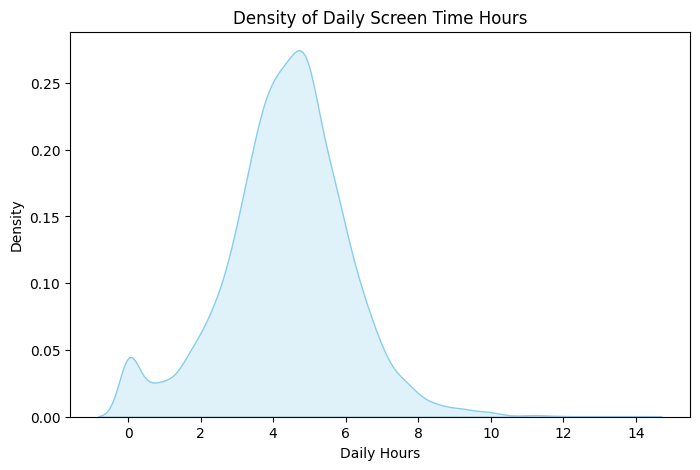

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['avg_daily_screen_time_hr'], fill=True, color='skyblue')
plt.title("Density of Daily Screen Time Hours")
plt.xlabel("Daily Hours")
plt.ylabel("Density")
plt.show()


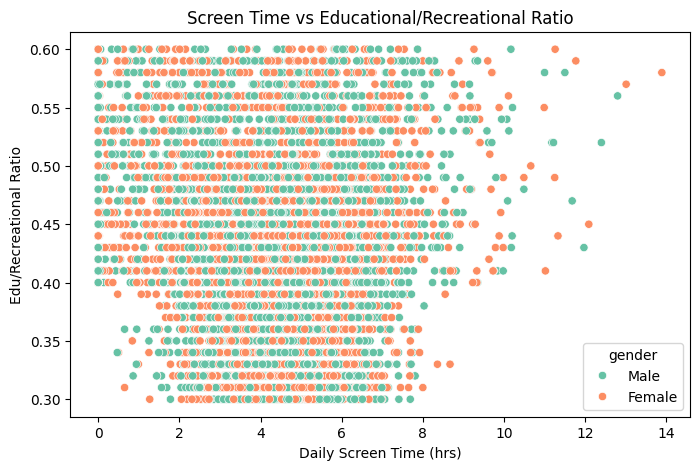

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='avg_daily_screen_time_hr', y='educational_to_recreational_ratio', hue='gender', data=df, palette='Set2')
plt.title("Screen Time vs Educational/Recreational Ratio")
plt.xlabel("Daily Screen Time (hrs)")
plt.ylabel("Edu/Recreational Ratio")
plt.show()


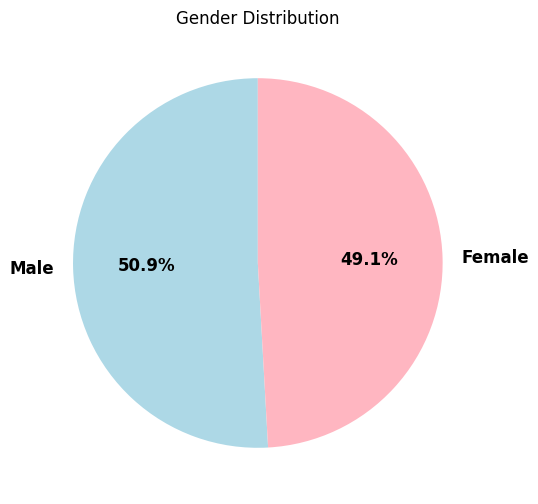

In [ ]:
gender_counts = df['gender'].value_counts()

plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['lightblue','lightpink'],
    textprops={'fontsize':12, 'weight':'bold'}
)

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_weight('bold')

plt.title("Gender Distribution")
plt.show()
